### Assignment 4. Mental Health Disorder Classification 

This assignment is to develop a decision tree model (random forests) to predict mental health disorder classification from a collection of symptoms.  The objective of this study is to determine whether we can develop quantitative analysis that predicts mental health diagnosis, and useful results that can inform practice (without doing all this analysis)
 
This data set is mostly categorical variables, e.g., mood swings (yes/no).  For categorical decision trees can make more intuitive sense since the boundaries separate the different categories.


In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV  # this is a new method
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance



- Load Data

In [16]:
df = pd.read_csv('cleaned_mental_disorder_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Sadness              120 non-null    object
 1   Euphoric             120 non-null    object
 2   Exhausted            120 non-null    object
 3   Sleep dissorder      120 non-null    object
 4   Mood Swing           120 non-null    object
 5   Suicidal thoughts    120 non-null    object
 6   Anorxia              120 non-null    object
 7   Authority Respect    120 non-null    object
 8   Try-Explanation      120 non-null    object
 9   Aggressive Response  120 non-null    object
 10  Ignore & Move-On     120 non-null    object
 11  Nervous Break-down   120 non-null    object
 12  Admit Mistakes       120 non-null    object
 13  Overthinking         120 non-null    object
 14  Sexual Activity      120 non-null    object
 15  Concentration        120 non-null    object
 16  Optimisi

Every single variable in this data set is categorical!  Lets take a quick look 

In [17]:
# display the first few rows
print("First few rows of the dataset:")
df.head(5)

First few rows of the dataset:


,Sadness,Euphoric,Exhausted,Sleep dissorder,Mood Swing,Suicidal thoughts,Anorxia,Authority Respect,Try-Explanation,Aggressive Response,Ignore & Move-On,Nervous Break-down,Admit Mistakes,Overthinking,Sexual Activity,Concentration,Optimisim,Expert Diagnose
0,Usually,Seldom,Sometimes,Sometimes,YES,YES,NO,NO,YES,NO,NO,YES,YES,YES,3 From 10,3 From 10,4 From 10,Bipolar Type-2
1,Usually,Seldom,Usually,Sometimes,NO,YES,NO,NO,NO,NO,NO,NO,NO,NO,4 From 10,2 From 10,5 From 10,Depression
2,Sometimes,Most-Often,Sometimes,Sometimes,YES,NO,NO,NO,YES,YES,NO,YES,YES,NO,6 From 10,5 From 10,7 From 10,Bipolar Type-1
3,Usually,Seldom,Usually,Most-Often,YES,YES,YES,NO,YES,NO,NO,NO,NO,NO,3 From 10,2 From 10,2 From 10,Bipolar Type-2
4,Usually,Usually,Sometimes,Sometimes,NO,NO,NO,NO,NO,NO,NO,YES,YES,YES,5 From 10,5 From 10,6 From 10,Normal


Use the scroll bar to look at all the variables.  
We can see that everything has been encoded as text strings, even potentially numeric variables like Sexual Acitivity, Concentration, and Optimism.  

Because I obsess about these things, I am going to fix the misspelling on two column headers. 

In [18]:
df = df.rename(columns={'Anorxia': 'Anorexia', 'Expert Diagnose':'Expert Diagnosis', 'Sleep dissorder':'Sleep disorder'})


1. Are there any missing values in the data set?  If there are remove those observations from the data. 

In [19]:
df.isnull().values.any()

False

Because this is categorical data, it will be useful to understand what are the possible values of each variable.  We can use the unique method to find this 

In [20]:
# check for unique value
for column in df.columns:
    unique_values = df[column].unique()
    print(f"\nUnique values in '{column}':\n{unique_values}")


Unique values in 'Sadness':
['Usually' 'Sometimes' 'Seldom' 'Most-Often']

Unique values in 'Euphoric':
['Seldom' 'Most-Often' 'Usually' 'Sometimes']

Unique values in 'Exhausted':
['Sometimes' 'Usually' 'Seldom' 'Most-Often']

Unique values in 'Sleep disorder':
['Sometimes' 'Most-Often' 'Usually' 'Seldom']

Unique values in 'Mood Swing':
['YES' 'NO']

Unique values in 'Suicidal thoughts':
['YES' 'NO']

Unique values in 'Anorexia':
['NO' 'YES']

Unique values in 'Authority Respect':
['NO' 'YES']

Unique values in 'Try-Explanation':
['YES' 'NO']

Unique values in 'Aggressive Response':
['NO' 'YES']

Unique values in 'Ignore & Move-On':
['NO' 'YES']

Unique values in 'Nervous Break-down':
['YES' 'NO']

Unique values in 'Admit Mistakes':
['YES' 'NO']

Unique values in 'Overthinking':
['YES' 'NO']

Unique values in 'Sexual Activity':
['3 From 10' '4 From 10' '6 From 10' '5 From 10' '7 From 10' '8 From 10'
 '9 From 10' '2 From 10' '1 From 10']

Unique values in 'Concentration':
['3 From 10

In [21]:
for col in ['Sadness','Euphoric','Exhausted','Sleep disorder']:
    print(col, df[col].unique())


Sadness ['Usually' 'Sometimes' 'Seldom' 'Most-Often']
Euphoric ['Seldom' 'Most-Often' 'Usually' 'Sometimes']
Exhausted ['Sometimes' 'Usually' 'Seldom' 'Most-Often']
Sleep disorder ['Sometimes' 'Most-Often' 'Usually' 'Seldom']


- There is of course a brute force approach to encoding this data numerically that could work, but thats throwing out the baby with the bath water. 

- There are 4 types of variables. 
    - 'Expert Diagnosis' has 4 categorical variables that bear no particular relationship.  Since this is the target variable for classification, we can actually leave them as is and it will facilitate making most of the tables and plots. DO NOT ENCODE!
    - 7 variables have 'YES' and 'NO' as the two possibilities.  It would be ideal to encode 'YES' as 1 and 'NO' as 0 
    - 3 variables are encoded as '3 from 10', etc.  This indicates that on a scale of 10 a numeric score of 3 was given.  These should be ideally converted to numeric values 
    - 4 variables have descriptive values, [Seldom' 'Sometimes' 'Usually' ''Most-Often'].   These are actually ordered values, wwith 'Seldom' as the least, and 'Most-Often' as the most.They should be numerically encoded to reflect their relative strength. 

Since we desire to make a careful encoding, using pd.get_dummies will not work that well.  We should instead be specific about the encoding.  Here is an example 

In [22]:
# desired encoding categorical variables

encoder = {'Seldom':1, 'Sometimes':2, 'Usually':3, 'Most-Often':4}
for j in df.columns[0:4]:
    df[j] = df[j].map(encoder)

df[['Sadness','Euphoric','Exhausted','Sleep disorder']].head()
df[['Sadness','Euphoric','Exhausted','Sleep disorder']].dtypes


Sadness           int64
Euphoric          int64
Exhausted         int64
Sleep disorder    int64
dtype: object

2. Using similar logic, encode the other predictor variables as numeric quantities.  

In [23]:



# -------- B. YES/NO variables encoded as 1/0 --------
yes_no_cols = [
    'Mood Swing',
    'Suicidal thoughts',
    'Anorexia',
    'Authority Respect',
    'Try-Explanation',
    'Aggressive Response',
    'Ignore & Move-On',
    'Nervous Break-down',
    'Admit Mistakes',
    'Overthinking'
]

for col in yes_no_cols:
    df[col] = df[col].map({'YES':1, 'NO':0})


# -------- C. “X From 10” score variables --------
score_cols = ['Sexual Activity', 'Concentration', 'Optimisim']

def extract_score(value):
    # converts '3 From 10' → 3
    return int(value.split()[0])

for col in score_cols:
    df[col] = df[col].apply(extract_score)


# -------- D. Leave Expert Diagnosis alone --------
# (Do nothing with: df['Expert Diagnosis'])


Exploratory Data Analysis - You need to do this to understand your results! 
Since these are all categorical variables, it makes the most sense to use histograms or count plots.  There are a lot of plots to look at.  When you do that, its very useful to come up with a systematic way to label things using colors to help your reader. 

3. Make a plot using sns.countplot that shows the number of patients with each diagnosis.  when you make this plot, choose the `palette` argument carefully, because this will assign each of the diagnosis a different color.  We want to keep that consistent throughout the notebook.  I  control this by setting `hue` = 'Expert Diagnosis' and `palette` = 'bright' but there are other popular palettes.  You can suppress the legend using `legend` = False.  Also take control of the order in which the different diagnosis are presented so they make sense, by provding the `order` as a list of the diagnoses.

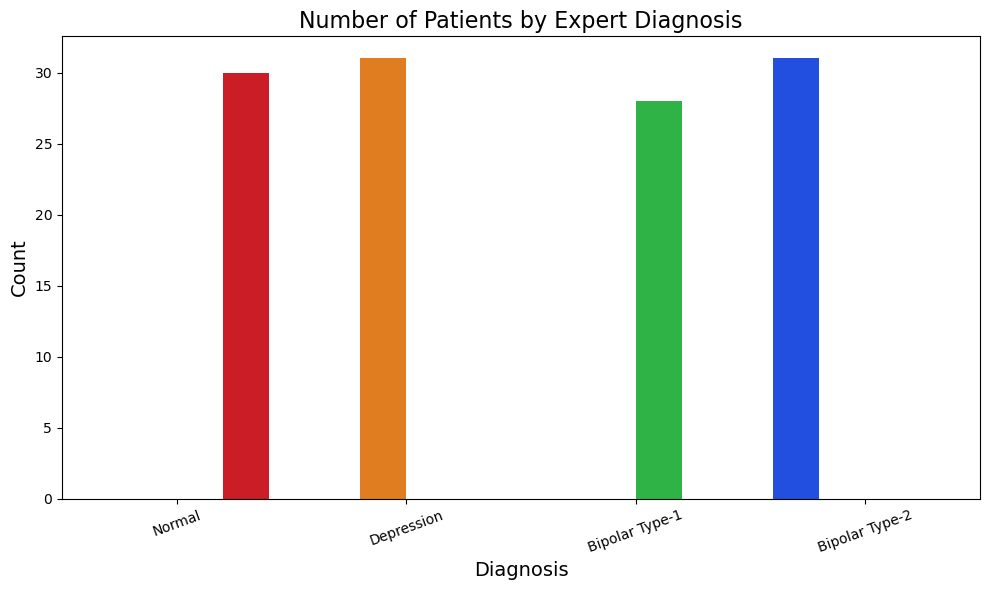

In [24]:
plt.figure(figsize=(10,6))

diagnosis_order = ['Normal', 'Depression', 'Bipolar Type-1', 'Bipolar Type-2']

ax = sns.countplot(
    data=df,
    x='Expert Diagnosis',
    hue='Expert Diagnosis',
    palette='bright',
    order=diagnosis_order
)

ax.legend_.remove()   # this disables the legend

plt.title('Number of Patients by Expert Diagnosis', fontsize=16)
plt.xlabel('Diagnosis', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


Now, plot all the predictors variables as histograms. My call inside a loop lindexed by i ooked like this - 

`sns.histplot(data=df, x=df.columns[i], hue='Expert Diagnosis', hue_order = ['Depression','Bipolar Type-1','Bipolar Type-2','Normal'],multiple="dodge", kde=True, palette="bright",legend=False)`

You dont need a legend here, because the previous plot assigned a color to each diagnosis and I am following the same color scheme here.  

In [25]:
df[['Sadness','Euphoric','Exhausted','Sleep disorder']].head(10)
for col in ['Sadness','Euphoric','Exhausted','Sleep disorder']:
    print(col, df[col].unique())



Sadness [3 2 1 4]
Euphoric [1 4 3 2]
Exhausted [2 3 1 4]
Sleep disorder [2 4 3 1]


<Figure size 300x200 with 0 Axes>

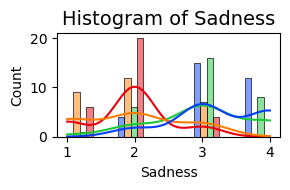

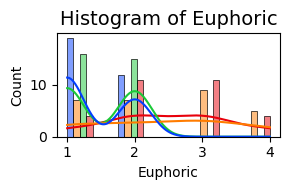

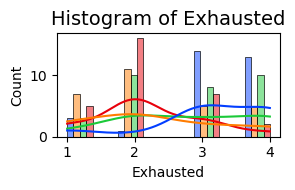

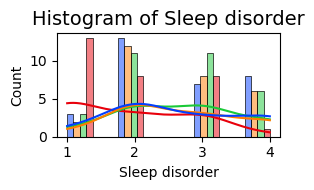

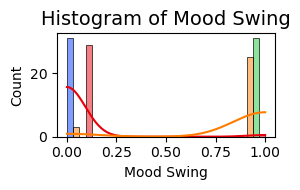

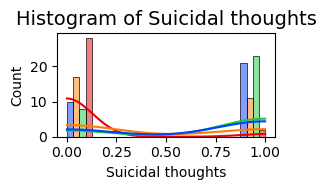

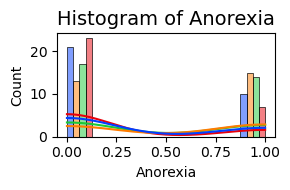

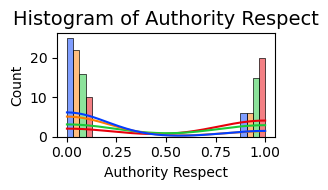

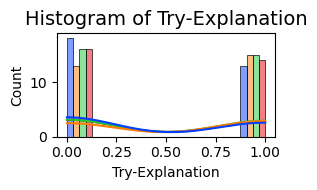

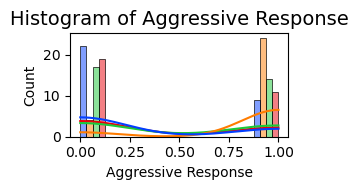

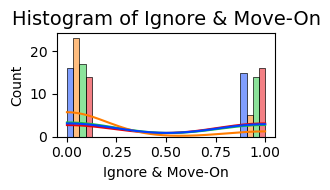

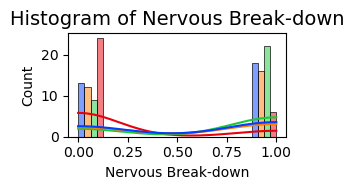

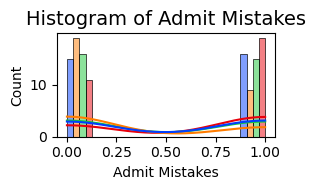

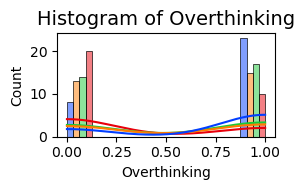

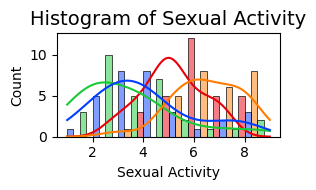

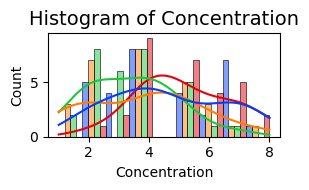

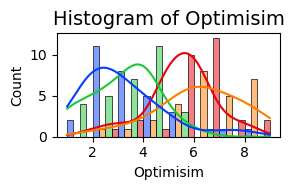

In [38]:
predictor_cols = df.columns.drop('Expert Diagnosis')

hue_order = ['Depression','Bipolar Type-1','Bipolar Type-2','Normal']

plt.figure(figsize=(3,2))

for i, col in enumerate(predictor_cols):
    plt.figure(figsize=(3,2))
    
    ax = sns.histplot(
        data=df,
        x=col,
        hue='Expert Diagnosis',
        hue_order=hue_order,
        multiple="dodge",
        kde=True,
        palette="bright"
    )
    
    # Remove legend (since color scheme already established)
    if ax.legend_:
        ax.legend_.remove()
    
    plt.title(f"Histogram of {col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


4.  Split the data into test and training sets. I put 30% into my test set.  Separate the target 'Expert Diagnosis' as the y variable and all the predictors as X.  
- **Its very important to stratify correctly.**  That is, we want the test data to be balanced in the same way as the training data.  
- If you called the target variable y, then include a parameter `stratify = y` when you split the data 

In [27]:
from sklearn.model_selection import train_test_split

# Separate predictors (X) and target (y)
X = df.drop('Expert Diagnosis', axis=1)
y = df['Expert Diagnosis']

# Split into training and test sets (30% test), stratifying by y
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,   # for reproducibility
    stratify=y         # ensures proportional representation of classes
)

# Quick check of class balance
print("Training set class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True))


Training set class distribution:
Bipolar Type-2    0.261905
Depression        0.261905
Normal            0.250000
Bipolar Type-1    0.226190
Name: Expert Diagnosis, dtype: float64

Test set class distribution:
Bipolar Type-2    0.25
Bipolar Type-1    0.25
Normal            0.25
Depression        0.25
Name: Expert Diagnosis, dtype: float64


5. Set up a random forest classifiers.  We need to use GridSearchCV to optimize two hyperparameters - `n_estimators`, the number of trees and max_depth.  I used n_estimators ranging from 100 to 400 and max_depth ranging from 1 to 5.  For scoring lets use accuracy.  I usually do 5-fold cross validation by default. Fit the classifier to the training data. 

Report 
    - best max-depth
    - best n_estimators
    - best Accuracy 

Extract the best rf model from your fit.   

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the Random Forest classifier
rf = RandomForestClassifier(random_state=42)

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [1, 2, 3, 4, 5]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,              # 5-fold cross-validation
    n_jobs=-1          # use all cores
)

# Fit to training data
grid_search.fit(X_train, y_train)

# Extract the best model
best_rf = grid_search.best_estimator_


print("Best max_depth:", grid_search.best_params_['max_depth'])
print("Best n_estimators:", grid_search.best_params_['n_estimators'])
print("Best cross-validated Accuracy:", grid_search.best_score_)



Best max_depth: 4
Best n_estimators: 400
Best cross-validated Accuracy: 0.9036764705882353


6. Evaluate your classifier by predicting the test data.

Present 

- the accuracy score 
- classification report.  

In the markdown below, write down what the precision and recall values are telling you about hen this model performs well

In [40]:
y_pred = best_rf.predict(X_test)
from sklearn.metrics import accuracy_score
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))



Test Accuracy: 0.8611111111111112
                precision    recall  f1-score   support

Bipolar Type-1       0.89      0.89      0.89         9
Bipolar Type-2       0.89      0.89      0.89         9
    Depression       0.82      1.00      0.90         9
        Normal       0.86      0.67      0.75         9

      accuracy                           0.86        36
     macro avg       0.86      0.86      0.86        36
  weighted avg       0.86      0.86      0.86        36



Comment on accuracy, precision, and recall. 



The model achieved a test accuracy of 0.86, meaning it correctly classified about 86% of all individuals in the test set. Accuracy is fairly high, but looking at precision and recall gives a clearer sense of where the model performs best. Precision for Bipolar Type-1, Bipolar Type-2, and Normal is strong (0.86–0.89), meaning that when the model predicts these diagnoses, it is usually correct. Recall for Depression is perfect (1.00), showing the model is especially good at identifying individuals who are actually depressed, with no missed cases. However, recall for the Normal class is lower (0.67), indicating the model often misclassifies Normal individuals as having a mental health condition. Overall, the classifier performs very well for detecting clinical conditions—especially Depression and both Bipolar types—but is less reliable at confirming when someone is truly symptom-free.


7. Make a confusion matrix to look at the pattern of misclassification.  When you do this, you will see that it labels the diagnoses as 0,1,2,3.  This is because internally, random forest mapped the conditions onto numeric values.  To find the mapping, look at `.classes_' of your best random forest object. In my case, it looked like this. 

['Bipolar Type-1' 'Bipolar Type-2' 'Depression' 'Normal']

so thats the order of conditions, and you should be able to fix your labels. 


Class order: ['Bipolar Type-1' 'Bipolar Type-2' 'Depression' 'Normal']


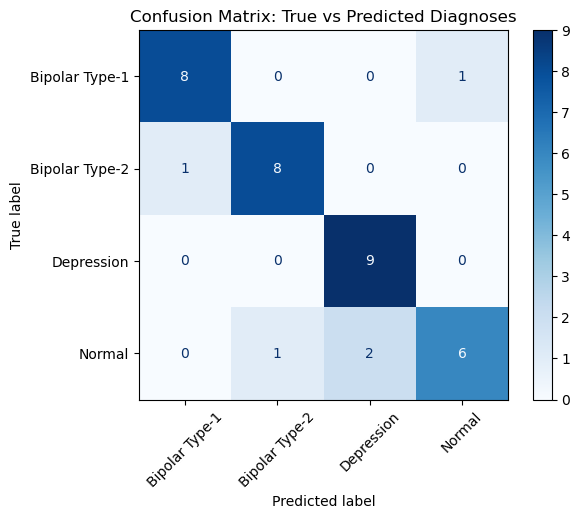

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Predict using the best random forest on the test set
y_pred = best_rf.predict(X_test)

# 2. Get the class order (internal numeric mapping)
class_order = best_rf.classes_
print("Class order:", class_order)

# 3. Create the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=class_order)

# 4. Display it with proper labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix: True vs Predicted Diagnoses")
plt.show()



8. To evaluate which predictors were useful for the classifier, use permutation_importance rather than partial dependence.  When we have more than 2 classes, permutation_important becomes harder to interpret as the model considers classifying one versus the rest.  Permutation importance tells us how much accuracy will decline if randomize the variable.  

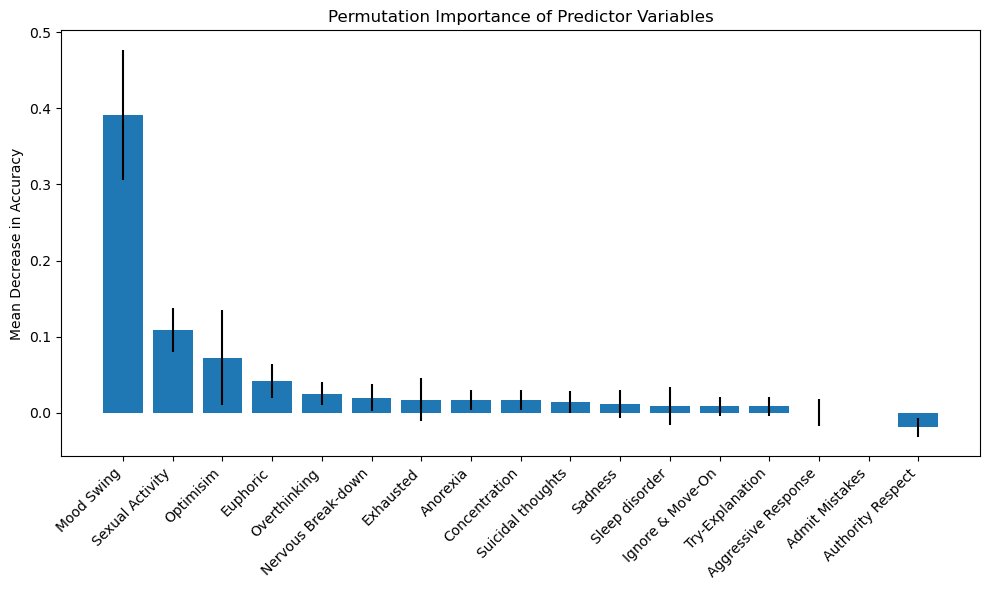

Mood Swing: 0.3917
Sexual Activity: 0.1083
Optimisim: 0.0722
Euphoric: 0.0417
Overthinking: 0.0250
Nervous Break-down: 0.0194
Exhausted: 0.0167
Anorexia: 0.0167
Concentration: 0.0167
Suicidal thoughts: 0.0139
Sadness: 0.0111
Sleep disorder: 0.0083
Ignore & Move-On: 0.0083
Try-Explanation: 0.0083
Aggressive Response: 0.0000
Admit Mistakes: 0.0000
Authority Respect: -0.0194


In [36]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

# Compute permutation importance on the test set
perm = permutation_importance(
    best_rf, 
    X_test, 
    y_test, 
    n_repeats=10,
    random_state=42
)

# Sort features by average importance
sorted_idx = perm.importances_mean.argsort()[::-1]

# Plot the permutation importance
plt.figure(figsize=(10,6))
plt.bar(
    range(len(X.columns)), 
    perm.importances_mean[sorted_idx],
    yerr=perm.importances_std[sorted_idx]
)
plt.xticks(range(len(X.columns)), X.columns[sorted_idx], rotation=45, ha='right')
plt.ylabel("Mean Decrease in Accuracy")
plt.title("Permutation Importance of Predictor Variables")
plt.tight_layout()
plt.show()

# Optionally print numeric values
for i in sorted_idx:
    print(f"{X.columns[i]}: {perm.importances_mean[i]:.4f}")


Write 1-2 paragraphs that summarizes

1.  what is the data and what is the question being asked of the data. 
2. what the model you made was, and how well the model performed.  What kind of errors if any does it make.  
3. What features of the data were most informative of mental health diagnosis.  
4. Can you provide a simple explanation of how to make a preliminary diagnosis that could be provided to counselors and first responders? 
5. If you had limited space and could only show a few of these figures, which ones would you show? 

1. The data is different mental diseases and how much symptoms of the different diseases effect the diagnosis. The different diseases were depression, bipolar type 1, bipolar type 2, and undiagnosed or normal. The questions being asked in this data is how often are these diseases mistaken for the other diseases in the list and what symptoms predict the diseases the best. The goal of this model was to build a machine learning model that can predict a person's diagnosis based on their symptoms.
2. I trained a Random Forest Classifier which achieved a cross-validated accuracy of ~.90. When it was evaluated on the test set, Normal and Depression were classified appropriately, but Bipolar Type-1 and Bipolar Type-2 had some mutual confusion. This makes sense because there is lots of overlapping symptoms in Bipolar Type-1 and Bipolar Type-2. 
3. The most informative predictor was mood swings and then sexual activity and then optomism. Mood swings was the predictor that gave the model the most information and the other two top predictors only gave a little bit of information. Using modd swings as the top predictor suggests that patterns of emotional regulation and mood instability are much stronger predictors of diagnosis in this dataset than individual depressive symptoms.
4. The permutation-importance results showed a range of symptom contributions, but the most meaningful takeaway is how these findings can guide preliminary assessments in real-world settings. The strongest indicators of diagnostic differences—especially mood swings (0.3917), sexual activity changes (0.1083), optimism shifts (0.0722), and euphoric episodes (0.0417)—suggest that counselors and first responders should pay particular attention to sudden or extreme changes in mood stability, energy, and risky or impulsive behavior. Secondary indicators such as overthinking (0.0250), nervous breakdown symptoms (0.0194), exhaustion (0.0167), appetite changes like anorexia (0.0167), concentration issues (0.0167), and suicidal thoughts (0.0139) can further help differentiate depression from bipolar presentations. Lower-impact features and those near zero contribute little to rapid assessment, meaning they may not be useful in a brief screening context. Overall, these results imply that a practical preliminary diagnosis should center on evaluating rapid mood fluctuation, behavioral impulsivity, and shifts in optimism or euphoria, as these variables provided the clearest statistical separation among mental-health conditions in the model.


5. The figures I would show if I only had limited space would be the countplot of diagnoses because it shows how the data set is distributed across the four diagnoses, confusion matrix to show how well the model preformed, and the permutation bar plot to show what symptoms are the best predictors.